## Exploratory Data Analysis

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# Load cleaned data
df = pd.read_csv("../data/birthwt_final_cleaned.csv")
df.head()

,low,age,lwt,smoke,ptl,ht,ui,ftv,bwt,has_ptl_history,high_risk,is_teen_mother,received_early_care,low_maternal_weight,race_black,race_other,race_white
0,False,19,182,False,0,False,True,0,2523,0,0,1,0,0,True,False,False
1,False,33,155,False,0,False,False,3,2551,0,0,0,1,0,False,True,False
2,False,20,105,True,0,False,False,1,2557,0,1,0,1,1,False,False,True
3,False,21,108,True,0,False,True,2,2594,0,1,0,1,1,False,False,True
4,False,18,107,True,0,False,True,0,2600,0,1,1,0,1,False,False,True


In [3]:
# Data Overview
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:")
df.describe(include='all').round(2)

Shape: (189, 17)

Column types:
 low                     bool
age                    int64
lwt                    int64
smoke                   bool
ptl                    int64
ht                      bool
ui                      bool
ftv                    int64
bwt                    int64
has_ptl_history        int64
high_risk              int64
is_teen_mother         int64
received_early_care    int64
low_maternal_weight    int64
race_black              bool
race_other              bool
race_white              bool
dtype: object

Missing values:
 low                    0
age                    0
lwt                    0
smoke                  0
ptl                    0
ht                     0
ui                     0
ftv                    0
bwt                    0
has_ptl_history        0
high_risk              0
is_teen_mother         0
received_early_care    0
low_maternal_weight    0
race_black             0
race_other             0
race_white             0
dtype: int64

Bas

,low,age,lwt,smoke,ptl,ht,ui,ftv,bwt,has_ptl_history,high_risk,is_teen_mother,received_early_care,low_maternal_weight,race_black,race_other,race_white
count,189,189.00,189.00,189,189.00,189,189,189.00,189.00,189.00,189.00,189.00,189.00,189.00,189,189,189
unique,2,NaN,NaN,2,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
top,False,NaN,NaN,False,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True
freq,130,NaN,NaN,115,NaN,177,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163,122,96
mean,NaN,23.24,129.81,NaN,0.20,NaN,NaN,0.79,2944.59,0.16,0.43,0.27,0.47,0.22,NaN,NaN,NaN
std,NaN,5.30,30.58,NaN,0.49,NaN,NaN,1.06,729.21,0.37,0.50,0.45,0.50,0.42,NaN,NaN,NaN
min,NaN,14.00,80.00,NaN,0.00,NaN,NaN,0.00,709.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN
25%,NaN,19.00,110.00,NaN,0.00,NaN,NaN,0.00,2414.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN
50%,NaN,23.00,121.00,NaN,0.00,NaN,NaN,0.00,2977.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN
75%,NaN,26.00,140.00,NaN,0.00,NaN,NaN,1.00,3487.00,0.00,1.00,1.00,1.00,0.00,NaN,NaN,NaN


In [5]:
# Encode Categorical Labels
# Convert True/False string values to boolean/int
bool_cols = ['low', 'smoke', 'ht', 'ui']
for col in bool_cols:
    df[col] = df[col].map({'True': True, 'False': False}).astype(bool)

# Reconstruct race from one-hot columns
df['race_label'] = 'Other'  # default
df.loc[df['race_white'] == True, 'race_label'] = 'White'
df.loc[df['race_black'] == True, 'race_label'] = 'Black'

# Readable labels for binary columns
df['smoke_label'] = df['smoke'].map({False: 'Non-smoker', True: 'Smoker'})
df['low_label'] = df['low'].map({False: 'Normal (≥2500g)', True: 'Low (<2500g)'})
df['ht_label'] = df['ht'].map({False: 'No Hypertension', True: 'Hypertension'})
df['ui_label'] = df['ui'].map({False: 'No UI', True: 'Uterine Irritability'})

# Verify
print("Race distribution:")
print(df['race_label'].value_counts())
print("\nSmoke distribution:")
print(df['smoke_label'].value_counts())
print("\nLow birth weight:")
print(df['low_label'].value_counts())

Race distribution:
race_label
White    96
Other    67
Black    26
Name: count, dtype: int64

Smoke distribution:
smoke_label
Smoker    189
Name: count, dtype: int64

Low birth weight:
low_label
Low (<2500g)    189
Name: count, dtype: int64


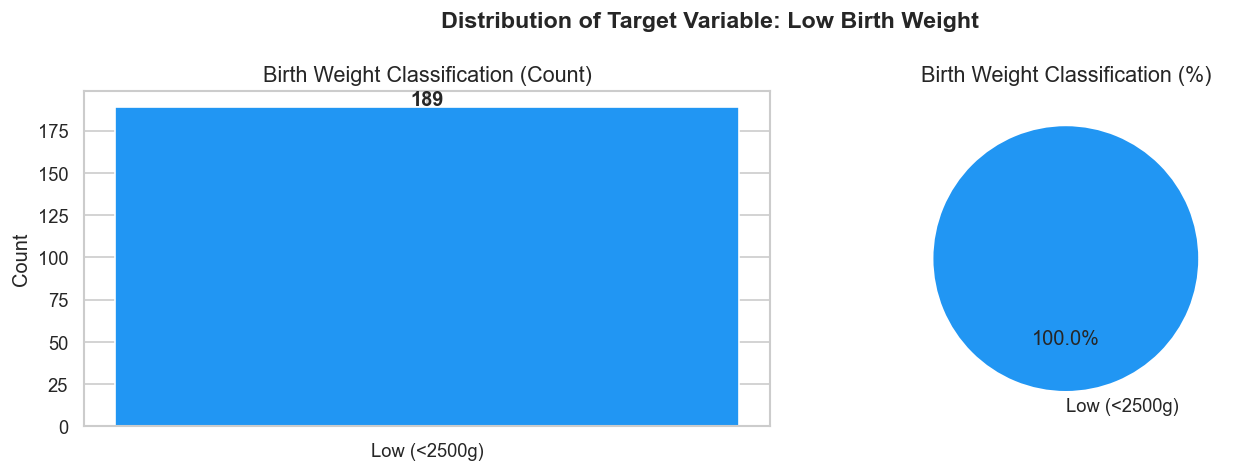


100.0% of births were classified as low birth weight (<2500g)


In [7]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
low_counts = df['low_label'].value_counts()
axes[0].bar(low_counts.index, low_counts.values, color=['#2196F3', '#F44336'])
axes[0].set_title('Birth Weight Classification (Count)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
for i, v in enumerate(low_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(low_counts.values, labels=low_counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Birth Weight Classification (%)', fontsize=13)

plt.suptitle('Distribution of Target Variable: Low Birth Weight', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../EDA_outputs/01_target_distribution.png', bbox_inches='tight')
plt.show()
print(f"\n{(df['low'].mean()*100):.1f}% of births were classified as low birth weight (<2500g)")

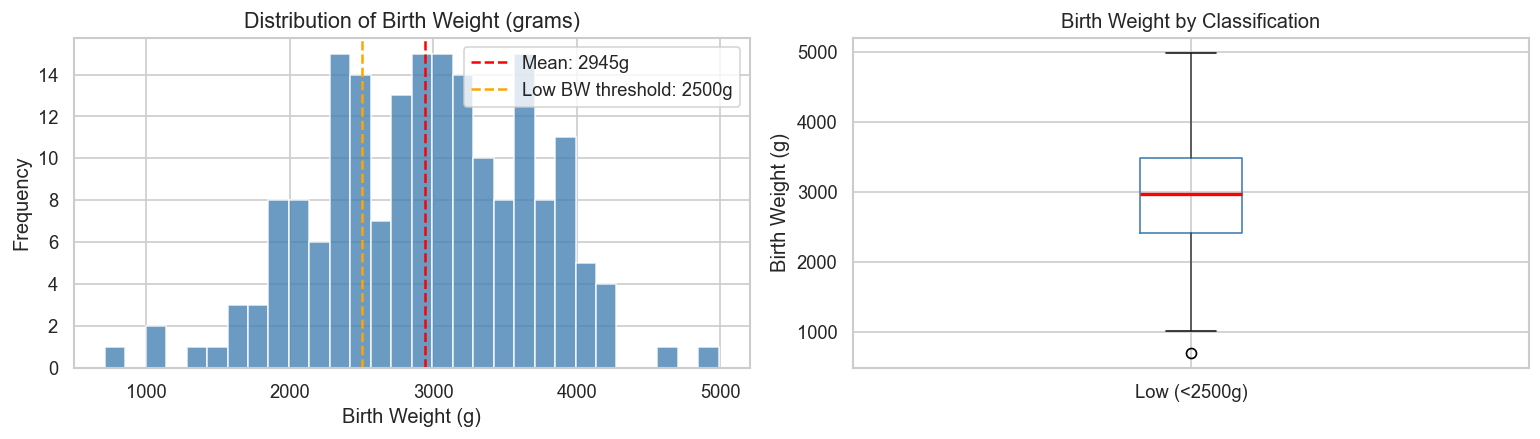

Mean bwt: 2944.6g  |  Median: 2977.0g  |  Std: 729.2g


In [8]:
# Birth Weight (bwt) Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['bwt'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['bwt'].mean(), color='red', linestyle='--', label=f"Mean: {df['bwt'].mean():.0f}g")
axes[0].axvline(2500, color='orange', linestyle='--', label='Low BW threshold: 2500g')
axes[0].set_title('Distribution of Birth Weight (grams)', fontsize=13)
axes[0].set_xlabel('Birth Weight (g)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot by low/normal
df.boxplot(column='bwt', by='low_label', ax=axes[1], 
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Birth Weight by Classification')
axes[1].set_xlabel('')
axes[1].set_ylabel('Birth Weight (g)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../EDA_outputs/02_bwt_distribution.png', bbox_inches='tight')
plt.show()

print(f"Mean bwt: {df['bwt'].mean():.1f}g  |  Median: {df['bwt'].median():.1f}g  |  Std: {df['bwt'].std():.1f}g")

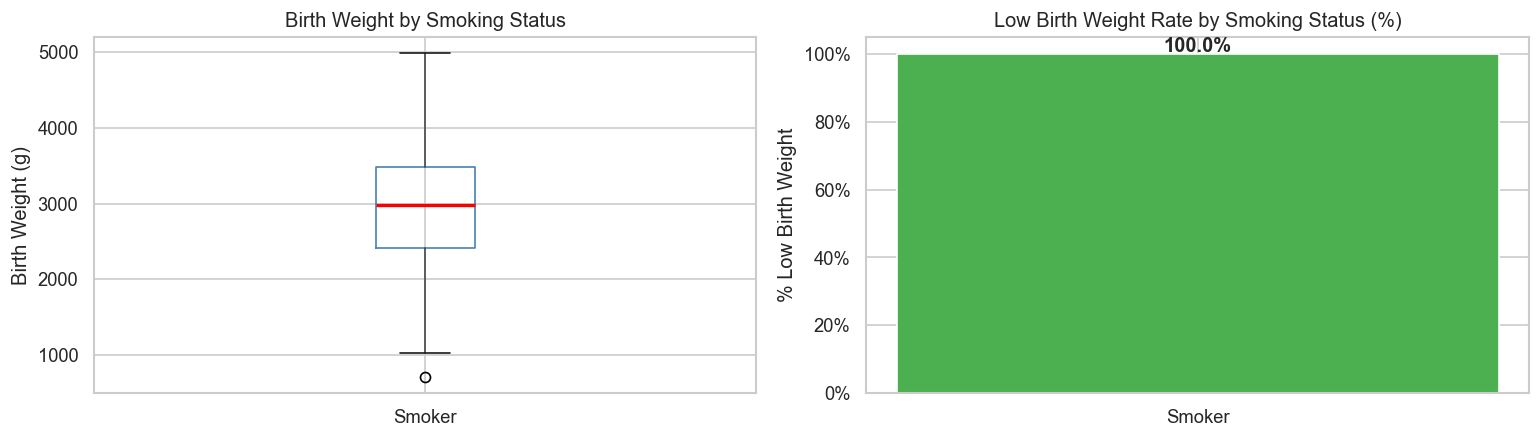

               mean  median    std
smoke_label                       
Smoker       2944.6  2977.0  729.2


In [9]:
# Smoking Status vs Birth Weight
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot
df.boxplot(column='bwt', by='smoke_label', ax=axes[0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Birth Weight by Smoking Status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Birth Weight (g)')
plt.suptitle('')

# Stacked bar: low birth weight rate by smoking
smoke_low = df.groupby('smoke_label')['low'].mean() * 100
axes[1].bar(smoke_low.index, smoke_low.values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Low Birth Weight Rate by Smoking Status (%)')
axes[1].set_ylabel('% Low Birth Weight')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(smoke_low.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../EDA_outputs/03_smoking_vs_bwt.png', bbox_inches='tight')
plt.show()

# Summary stats
print(df.groupby('smoke_label')['bwt'].agg(['mean', 'median', 'std']).round(1))

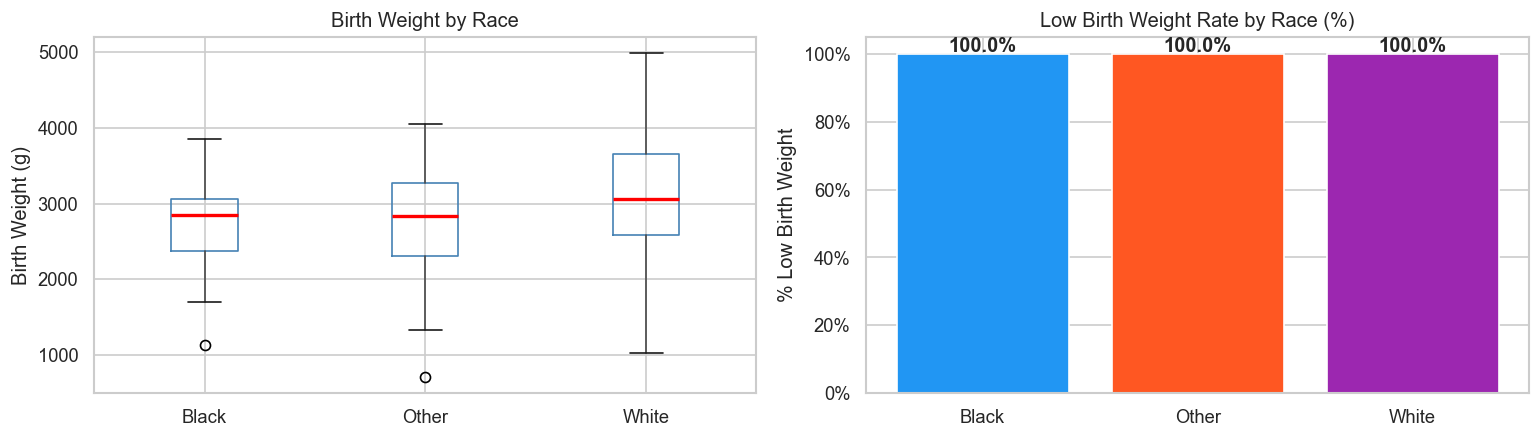

              mean  median    std
race_label                       
Black       2719.7  2849.0  638.7
Other       2805.3  2835.0  722.2
White       3102.7  3062.0  727.9


In [10]:
# Race vs Birth Weight
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot(column='bwt', by='race_label', ax=axes[0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Birth Weight by Race')
axes[0].set_xlabel('')
axes[0].set_ylabel('Birth Weight (g)')
plt.suptitle('')

race_low = df.groupby('race_label')['low'].mean() * 100
axes[1].bar(race_low.index, race_low.values, color=['#2196F3', '#FF5722', '#9C27B0'])
axes[1].set_title('Low Birth Weight Rate by Race (%)')
axes[1].set_ylabel('% Low Birth Weight')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(race_low.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../EDA_outputs/04_race_vs_bwt.png', bbox_inches='tight')
plt.show()

print(df.groupby('race_label')['bwt'].agg(['mean', 'median', 'std']).round(1))

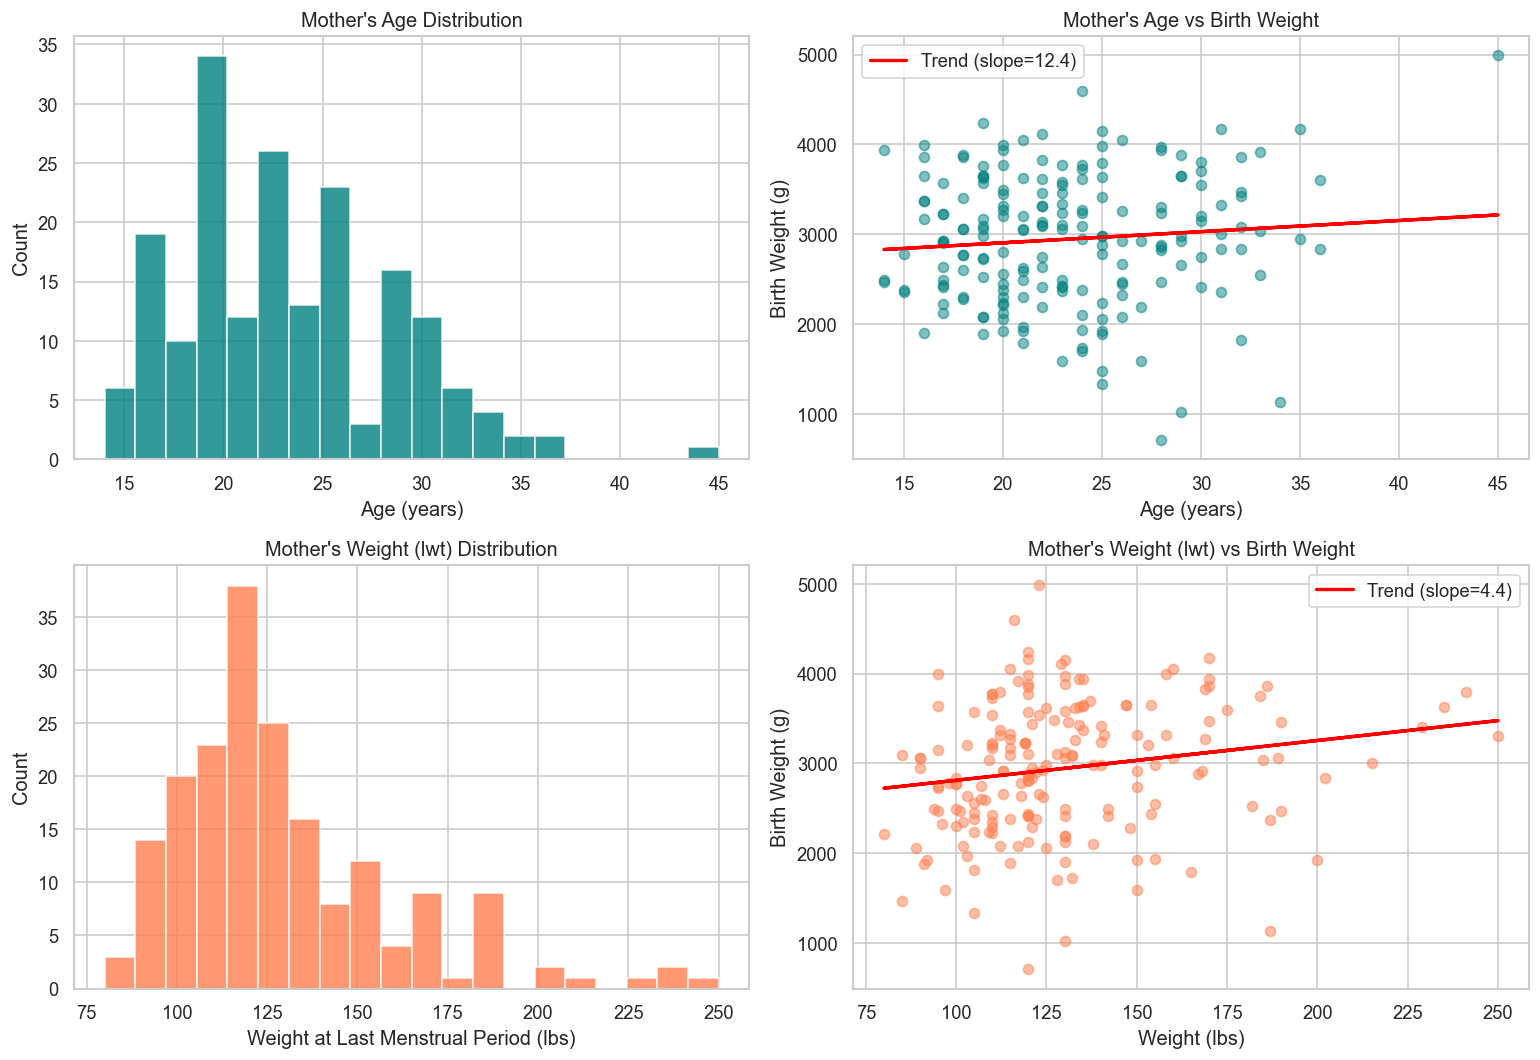

In [11]:
# Continuous Variables: Age & Maternal Weight (lwt)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# age distribution
axes[0,0].hist(df['age'], bins=20, color='teal', edgecolor='white', alpha=0.8)
axes[0,0].set_title("Mother's Age Distribution")
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Count')

# age vs bwt scatter
axes[0,1].scatter(df['age'], df['bwt'], alpha=0.5, color='teal')
m, b = np.polyfit(df['age'], df['bwt'], 1)
axes[0,1].plot(df['age'], m*df['age']+b, color='red', linewidth=2, label=f'Trend (slope={m:.1f})')
axes[0,1].set_title("Mother's Age vs Birth Weight")
axes[0,1].set_xlabel('Age (years)')
axes[0,1].set_ylabel('Birth Weight (g)')
axes[0,1].legend()

# lwt distribution
axes[1,0].hist(df['lwt'], bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1,0].set_title("Mother's Weight (lwt) Distribution")
axes[1,0].set_xlabel('Weight at Last Menstrual Period (lbs)')
axes[1,0].set_ylabel('Count')

# lwt vs bwt scatter
axes[1,1].scatter(df['lwt'], df['bwt'], alpha=0.5, color='coral')
m2, b2 = np.polyfit(df['lwt'], df['bwt'], 1)
axes[1,1].plot(df['lwt'], m2*df['lwt']+b2, color='red', linewidth=2, label=f'Trend (slope={m2:.1f})')
axes[1,1].set_title("Mother's Weight (lwt) vs Birth Weight")
axes[1,1].set_xlabel('Weight (lbs)')
axes[1,1].set_ylabel('Birth Weight (g)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../EDA_outputs/05_continuous_vars.png', bbox_inches='tight')
plt.show()

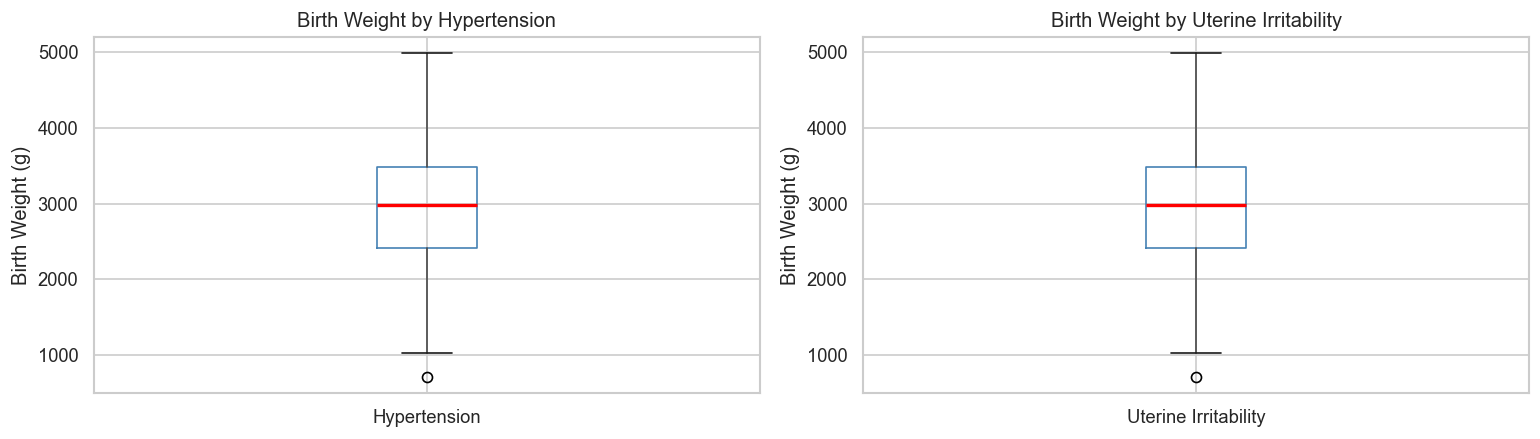


Low BW rate by Hypertension:
ht_label
Hypertension    100.0
Name: low, dtype: float64

Low BW rate by Uterine Irritability:
ui_label
Uterine Irritability    100.0
Name: low, dtype: float64


In [12]:
# Binary Risk Factors (ht, ui,ptl)
risk_vars = {
    'ht_label': 'Hypertension',
    'ui_label': 'Uterine Irritability'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (col, title) in zip(axes, risk_vars.items()):
    df.boxplot(column='bwt', by=col, ax=ax,
               boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Birth Weight by {title}')
    ax.set_xlabel('')
    ax.set_ylabel('Birth Weight (g)')
    plt.suptitle('')

plt.tight_layout()
plt.savefig('../EDA_outputs/06_risk_factors_bwt.png', bbox_inches='tight')
plt.show()

# Rates
for col, lbl in [('ht_label','Hypertension'), ('ui_label','Uterine Irritability')]:
    rate = df.groupby(col)['low'].mean()*100
    print(f"\nLow BW rate by {lbl}:\n{rate.round(1)}")

In [14]:
# Correlation Heatmap
numeric_cols = ['bwt', 'age', 'lwt', 'ptl', 'ftv',
                'race_white', 'race_black', 'race_other',
                'high_risk', 'has_ptl_history',
                'is_teen_mother', 'received_early_care', 'low_maternal_weight']
# Convert bool cols to int for correlation
corr_df = df[numeric_cols].copy()
for c in corr_df.select_dtypes('bool').columns:
    corr_df[c] = corr_df[c].astype(int)
corr = corr_df.corr()

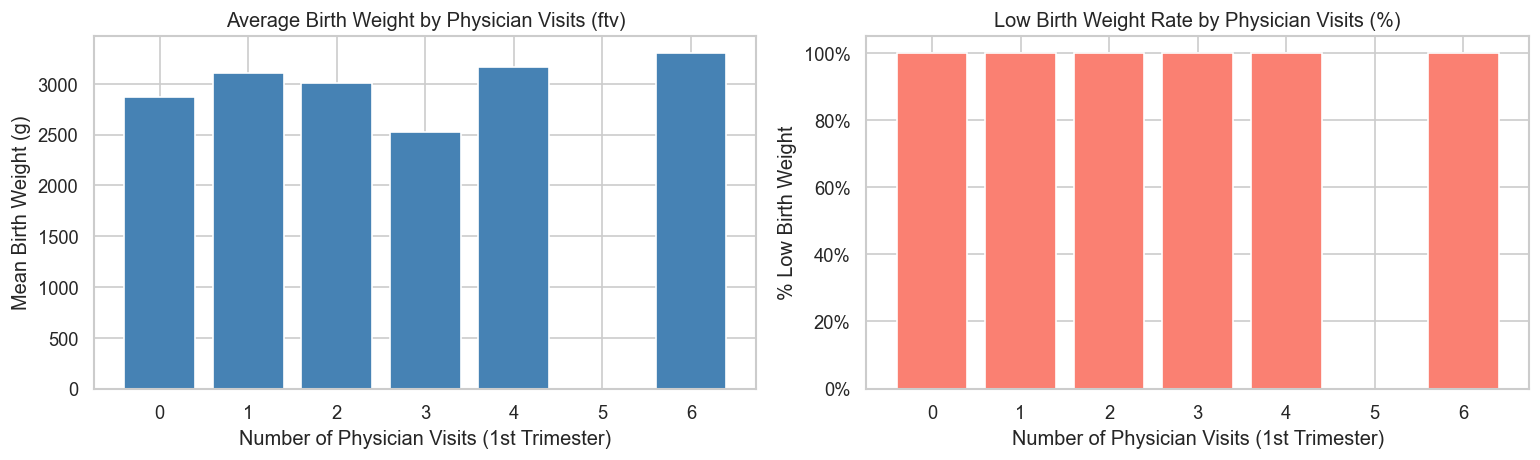

In [15]:
# Physician Visits (ftv) vs Birth Weight
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

visit_bwt = df.groupby('ftv')['bwt'].mean()
axes[0].bar(visit_bwt.index, visit_bwt.values, color='steelblue', edgecolor='white')
axes[0].set_title('Average Birth Weight by Physician Visits (ftv)')
axes[0].set_xlabel('Number of Physician Visits (1st Trimester)')
axes[0].set_ylabel('Mean Birth Weight (g)')

visit_low = df.groupby('ftv')['low'].mean() * 100
axes[1].bar(visit_low.index, visit_low.values, color='salmon', edgecolor='white')
axes[1].set_title('Low Birth Weight Rate by Physician Visits (%)')
axes[1].set_xlabel('Number of Physician Visits (1st Trimester)')
axes[1].set_ylabel('% Low Birth Weight')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('../EDA_outputs/08_ftv_vs_bwt.png', bbox_inches='tight')
plt.show()

In [19]:
print("="*60)
print("EDA SUMMARY — Key Findings")
print("="*60)

# 1. Dataset overview
print(f"\n1. Dataset: {df.shape[0]} births, {df.shape[1]} variables")
print(f"   Low birth weight cases: {df['low'].sum()} ({df['low'].mean()*100:.1f}%)")

# 2. Smoking
print(f"\n2. Smoking (avg birth weight):")
print(df.groupby('smoke_label')['bwt'].mean().round(1).to_string())
smoke_means = df.groupby('smoke_label')['bwt'].mean()
if 'Non-smoker' in smoke_means.index and 'Smoker' in smoke_means.index:
    diff = smoke_means['Non-smoker'] - smoke_means['Smoker']
    print(f"   → Smokers have {diff:.0f}g lower avg birth weight")

# 3. Race
print(f"\n3. Race (avg birth weight):")
print(df.groupby('race_label')['bwt'].mean().round(1).to_string())

# 4. Hypertension
print(f"\n4. Hypertension (avg birth weight):")
print(df.groupby('ht_label')['bwt'].mean().round(1).to_string())

# 5. Uterine Irritability
print(f"\n5. Uterine Irritability (avg birth weight):")
print(df.groupby('ui_label')['bwt'].mean().round(1).to_string())

# 6. Correlation with bwt
print(f"\n6. Top correlations with bwt:")
corr_cols = ['bwt', 'age', 'lwt', 'ptl', 'ftv',
             'race_white', 'race_black', 'race_other',
             'high_risk', 'has_ptl_history',
             'is_teen_mother', 'received_early_care', 'low_maternal_weight']
corr_df_s = df[corr_cols].copy()
for c in corr_df_s.select_dtypes('bool').columns:
    corr_df_s[c] = corr_df_s[c].astype(int)
corr_bwt = corr_df_s.corr()['bwt'].drop('bwt').sort_values()
print(corr_bwt.round(3).to_string())

EDA SUMMARY — Key Findings

1. Dataset: 189 births, 22 variables
   Low birth weight cases: 189 (100.0%)

2. Smoking (avg birth weight):
smoke_label
Smoker    2944.6

3. Race (avg birth weight):
race_label
Black    2719.7
Other    2805.3
White    3102.7

4. Hypertension (avg birth weight):
ht_label
Hypertension    2944.6

5. Uterine Irritability (avg birth weight):
ui_label
Uterine Irritability    2944.6

6. Top correlations with bwt:
low_maternal_weight   -0.291
high_risk             -0.232
has_ptl_history       -0.218
ptl                   -0.155
race_other            -0.142
race_black            -0.124
is_teen_mother         0.024
ftv                    0.058
age                    0.090
received_early_care    0.116
lwt                    0.186
race_white             0.221
